In [1]:
import numpy as np
import pandas as pd

In [2]:
X_train = pd.read_csv('loan_data_X_train.csv', index_col=0)
X_test = pd.read_csv('loan_data_X_test.csv', index_col=0)
y_train = pd.read_csv('loan_data_y_train.csv', index_col=0)
y_test = pd.read_csv('loan_data_y_test.csv', index_col=0)

In [3]:
X_train.shape, X_test.shape

((373028, 238), (93257, 238))

In [4]:
inputs_train_with_ref_cat = X_train.loc[:, [
    'grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G',
    'home_ownership:OWN', 'home_ownership:MORTGAGE', 'home_ownership:RENT_OTHER_NONE_ANY',
    'verification_status:Source Verified', 'verification_status:Not Verified', 'verification_status:Verified',
    'purpose:small_business_educational', 'purpose:moving_house_other_renewable_energy_medical',
    'purpose:vacation_debt_consolidation_wedding', 'purpose:home_improvement_major_purchase_car_credit_card',
    'addr_state:NE_IA_ME_ID', 'addr_state:NV_AL_HI_FL', 'addr_state:NM_NY_OK_TN_VA_LA_MD_NC_MO_CA_NJ_PA_AZ_AR',
    'addr_state:UT_KY_MI_MN_RI_OH_IN_MA_DE_SD_GA_WA_OR_WI_MT_MS', 'addr_state:TX_CT_IL_SC_KS_CO_VT_AK',
    'addr_state:WV_NH_WY_DC',
    'initial_list_status:f', 'initial_list_status:w',
    'term:36', 'term:60',
    'mths_since_earliest_issue_d:<38', 'mths_since_earliest_issue_d:38-48',
    'mths_since_earliest_issue_d:48-56', 'mths_since_earliest_issue_d:56-72',
    'mths_since_earliest_issue_d:72-84', 'mths_since_earliest_issue_d:>84',
    'int_rate:<9.548', 'int_rate:9.548-12.025', 'int_rate:12.025-15.74',
    'int_rate:15.74-20.281', 'int_rate:>20.281',
    'delinq_2yrs:0', 'delinq_2yrs:1-2', 'delinq_2yrs:3+',
    'inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:3-6', 'inq_last_6mths:>6',
    'open_acc:0', 'open_acc:1-3', 'open_acc:4-12', 'open_acc:13-17',
    'open_acc:18-22', 'open_acc:23-25', 'open_acc:26-30', 'open_acc:>=31',
    'pub_rec:0-2', 'pub_rec:3-4', 'pub_rec:>=5',
    'total_acc:<=27', 'total_acc:28-51', 'total_acc:>=52',
    'acc_now_delinq:0', 'acc_now_delinq:>=1',
    'total_rev_hi_lim:<=5K', 'total_rev_hi_lim:5K-10K', 'total_rev_hi_lim:10K-20K',
    'total_rev_hi_lim:20K-30K', 'total_rev_hi_lim:30K-40K', 'total_rev_hi_lim:40K-55K',
    'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K',
    'annual_inc:<20K', 'annual_inc:20K-30K', 'annual_inc:30K-40K', 'annual_inc:40K-50K',
    'annual_inc:50K-60K', 'annual_inc:60K-70K', 'annual_inc:70K-80K', 'annual_inc:80K-90K',
    'annual_inc:90K-100K', 'annual_inc:100K-120K', 'annual_inc:120K-140K', 'annual_inc:>140K',
    'dti:<=1.4', 'dti:1.4-10.5', 'dti:10.5-16', 'dti:16-22', 'dti:22-30', 'dti:>30'
]]

inputs_train_with_ref_cat.shape

(373028, 87)

In [5]:
ref_categories = [
    'grade:G',
    'home_ownership:RENT_OTHER_NONE_ANY',
    'verification_status:Verified',
    'purpose:home_improvement_major_purchase_car_credit_card',
    'addr_state:NE_IA_ME_ID',
    'initial_list_status:f',
    'term:60',
    'mths_since_earliest_issue_d:>84',
    'int_rate:>20.281',
    'delinq_2yrs:3+',
    'inq_last_6mths:>6',
    'open_acc:>=31',
    'pub_rec:0-2',
    'total_acc:>=52',
    'acc_now_delinq:>=1',
    'total_rev_hi_lim:<=5K',
    'annual_inc:<20K',
    'dti:>30'
]

inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis=1)
inputs_train.shape

(373028, 69)

In [6]:
from sklearn.linear_model import LogisticRegression
from scipy import stats

class LogisticRegression_with_p_values:
    def __init__(self, *args, **kwargs):
        self.model = LogisticRegression(*args, **kwargs)
    
    def fit(self, X, y):
        self.model.fit(X, y)
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom, (X.shape[1], 1)).T
        F_ij = np.dot((X / denom).T, X)
        Cramer_Rao = np.linalg.inv(F_ij)
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = (1 - stats.norm.cdf(np.abs(z_scores))) * 2
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)

In [7]:
reg = LogisticRegression_with_p_values()
reg.fit(inputs_train, y_train.values.ravel())

In [8]:
feature_name = inputs_train.columns.values

summary_table = pd.DataFrame(columns=['Feature name'], data=feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()

p_values = reg.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values

summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.154900,NaN
1,grade:A,-0.945213,0.000000e+00
2,grade:B,-0.729682,0.000000e+00
3,grade:C,-0.555332,0.000000e+00
4,grade:D,-0.392444,8.060219e-14
...,...,...,...
65,dti:<=1.4,-0.163787,1.262977e-02
66,dti:1.4-10.5,-0.246839,0.000000e+00
67,dti:10.5-16,-0.153754,4.926859e-11
68,dti:16-22,-0.045089,4.457851e-02


In [9]:
pd.options.display.max_rows=None

In [10]:
summary_table[summary_table['p_values'] > 0.05]

,Feature name,Coefficients,p_values
6,grade:F,-0.087532,0.074519
9,verification_status:Source Verified,0.002906,0.821428
14,addr_state:NV_AL_HI_FL,0.137538,0.432844
15,addr_state:NM_NY_OK_TN_VA_LA_MD_NC_MO_CA_NJ_PA...,0.078199,0.654653
16,addr_state:UT_KY_MI_MN_RI_OH_IN_MA_DE_SD_GA_WA...,-0.008987,0.959028
17,addr_state:TX_CT_IL_SC_KS_CO_VT_AK,-0.118417,0.498853
18,addr_state:WV_NH_WY_DC,-0.306522,0.090097
24,mths_since_earliest_issue_d:56-72,-0.049375,0.076300
25,mths_since_earliest_issue_d:72-84,0.018344,0.563977
34,inq_last_6mths:3-6,-0.073605,0.535469


In [11]:
inputs_train2 = inputs_train.drop(columns=[
    'grade:F',
    'verification_status:Source Verified',
    'addr_state:NV_AL_HI_FL',
    'addr_state:NM_NY_OK_TN_VA_LA_MD_NC_MO_CA_NJ_PA_AZ_AR',
    'addr_state:UT_KY_MI_MN_RI_OH_IN_MA_DE_SD_GA_WA_OR_WI_MT_MS',
    'addr_state:TX_CT_IL_SC_KS_CO_VT_AK',
    'addr_state:WV_NH_WY_DC',
    'mths_since_earliest_issue_d:56-72',
    'mths_since_earliest_issue_d:72-84',
    'inq_last_6mths:3-6',
    'open_acc:0',
    'open_acc:4-12',
    'open_acc:13-17',
    'open_acc:18-22',
    'open_acc:23-25',
    'open_acc:26-30',
    'pub_rec:>=5',
    'annual_inc:30K-40K',
    'annual_inc:40K-50K',
    'dti:22-30'
])

reg2 = LogisticRegression_with_p_values()
reg2.fit(inputs_train2, y_train.values.ravel())

In [12]:
feature_name = inputs_train2.columns.values

summary_table = pd.DataFrame(columns=['Feature name'], data=feature_name)
summary_table['Coefficients'] = np.transpose(reg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
summary_table = summary_table.sort_index()

p_values = reg2.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values

summary_table[summary_table['p_values'] > 0.05]

,Feature name,Coefficients,p_values
27,total_acc:<=27,0.053695,0.102752
28,total_acc:28-51,0.054145,0.099744
29,acc_now_delinq:0,0.067068,0.176395


In [13]:
inputs_train3 = inputs_train2.drop(columns=[
    'total_acc:<=27',
    'total_acc:28-51',
    'acc_now_delinq:0'
])

reg3 = LogisticRegression_with_p_values()
reg3.fit(inputs_train3, y_train.values.ravel())

In [14]:
feature_name = inputs_train3.columns.values

summary_table = pd.DataFrame(columns=['Feature name'], data=feature_name)
summary_table['Coefficients'] = np.transpose(reg3.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg3.intercept_[0]]
summary_table = summary_table.sort_index()

p_values = reg3.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values

summary_table[summary_table['p_values'] > 0.05]

,Feature name,Coefficients,p_values
21,delinq_2yrs:0,-0.024284,0.338533
22,delinq_2yrs:1-2,-0.017448,0.532817
25,open_acc:1-3,-0.069238,0.088130
26,pub_rec:3-4,-0.125645,0.123594
27,total_rev_hi_lim:5K-10K,-0.035505,0.115068
28,total_rev_hi_lim:10K-20K,-0.023867,0.260541
29,total_rev_hi_lim:20K-30K,-0.039149,0.089278


In [15]:
inputs_train4 = inputs_train3.drop(columns=[
    'delinq_2yrs:0',
    'delinq_2yrs:1-2',
    'open_acc:1-3',
    'pub_rec:3-4',
    'total_rev_hi_lim:5K-10K',
    'total_rev_hi_lim:10K-20K',
    'total_rev_hi_lim:20K-30K'
])

reg4 = LogisticRegression_with_p_values()
reg4.fit(inputs_train4, y_train.values.ravel())

In [16]:
feature_name = inputs_train4.columns.values

summary_table = pd.DataFrame(columns=['Feature name'], data=feature_name)
summary_table['Coefficients'] = np.transpose(reg4.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg4.intercept_[0]]
summary_table = summary_table.sort_index()

p_values = reg4.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values

summary_table[summary_table['p_values'] > 0.05]

,Feature name,Coefficients,p_values


In [17]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-0.125378,NaN
1,grade:A,-0.908212,0.000000e+00
2,grade:B,-0.668930,0.000000e+00
3,grade:C,-0.488960,0.000000e+00
4,grade:D,-0.318260,0.000000e+00
5,grade:E,-0.181616,8.215650e-15
6,home_ownership:OWN,-0.102212,7.099440e-08
7,home_ownership:MORTGAGE,-0.137560,0.000000e+00
8,verification_status:Not Verified,-0.090637,4.087841e-13
9,purpose:small_business_educational,0.549410,0.000000e+00


In [18]:
inputs_test4 = X_test[inputs_train4.columns]

In [19]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_hat_test = reg4.model.predict_proba(inputs_test4)[:, 1]

auc = roc_auc_score(y_test, y_hat_test)
print('AUC-ROC:', auc)

AUC-ROC: 0.6895328473200997


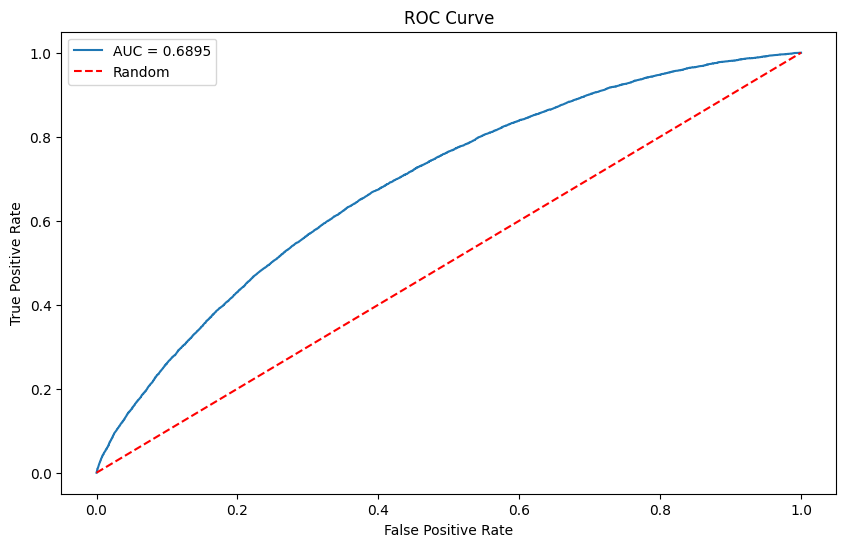

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_hat_test)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label='AUC = %0.4f' % auc)
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
#True positive -> reality bad, prediction bad
#False positive -> reality good, prediction bad

In [21]:
# Gini
gini = 2 * auc - 1
print('Gini:', gini)

# KS
ks = max(tpr - fpr)
print('KS:', ks)

Gini: 0.37906569464019935
KS: 0.2770926059532763


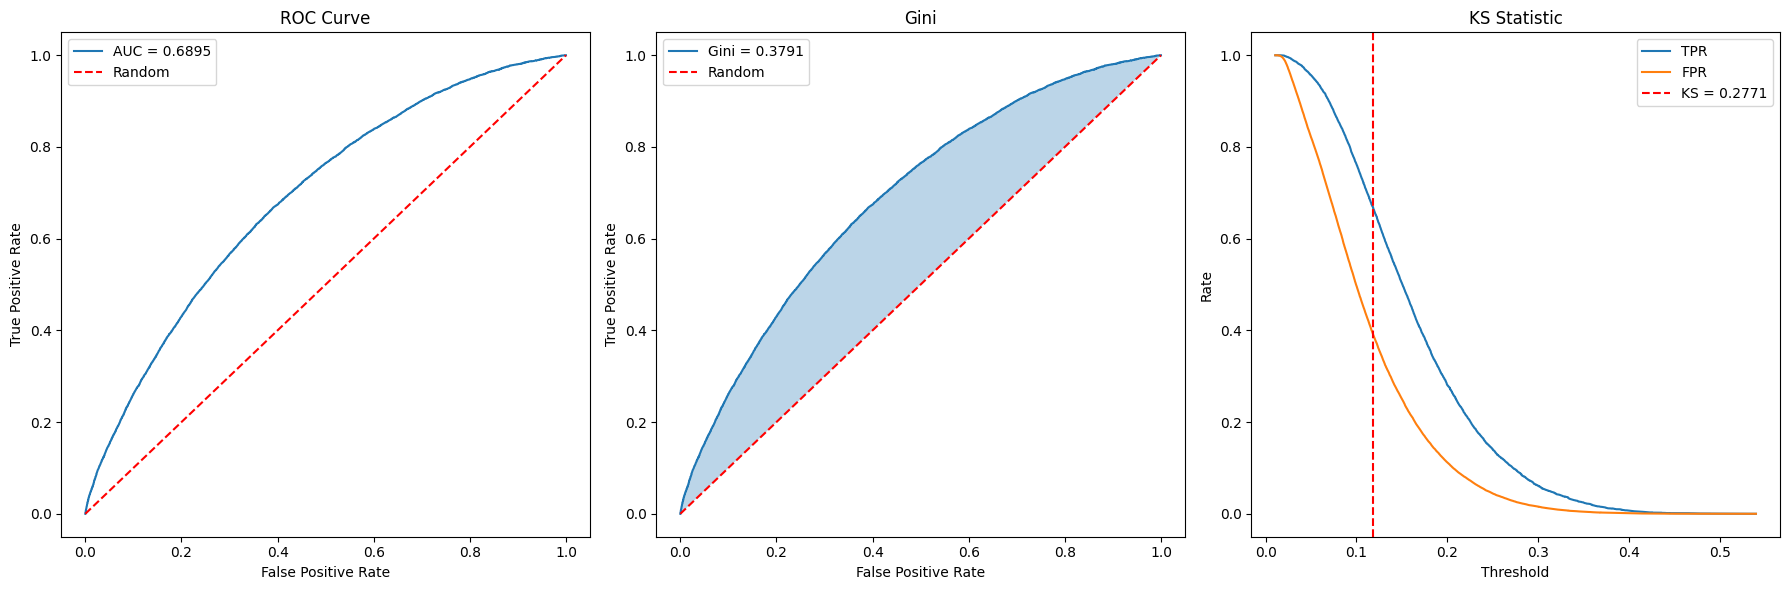

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ROC Curve
axes[0].plot(fpr, tpr, label='AUC = %0.4f' % auc)
axes[0].plot([0, 1], [0, 1], 'r--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Gini
axes[1].plot(fpr, tpr, label='Gini = %0.4f' % gini)
axes[1].plot([0, 1], [0, 1], 'r--', label='Random')
axes[1].fill_between(fpr, tpr, fpr, alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Gini')
axes[1].legend()

# KS
axes[2].plot(thresholds, tpr, label='TPR')
axes[2].plot(thresholds, fpr, label='FPR')
axes[2].axvline(x=thresholds[np.argmax(tpr - fpr)], color='r', linestyle='--',
                label='KS = %0.4f' % ks)
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Rate')
axes[2].set_title('KS Statistic')
axes[2].legend()

plt.tight_layout()
plt.show()

## Scorecard (300~850)

In [23]:
# Parameters
min_score = 300
max_score = 850
pdo = 20
target_score = 600
target_odds = 19
factor = pdo / np.log(2)
offset = target_score - factor * np.log(target_odds)

print('Factor:', factor)
print('Offset:', offset)

Factor: 28.85390081777927
Offset: 515.0414497311283


In [24]:
summary_table['Score'] = summary_table['Coefficients'] * (-factor)

summary_table.loc[0, 'Score'] = offset + reg4.intercept_[0] * (-factor)

summary_table

,Feature name,Coefficients,p_values,Score
0,Intercept,-0.125378,NaN,518.659088
1,grade:A,-0.908212,0.000000e+00,26.205459
2,grade:B,-0.668930,0.000000e+00,19.301245
3,grade:C,-0.488960,0.000000e+00,14.108394
4,grade:D,-0.318260,0.000000e+00,9.183032
5,grade:E,-0.181616,8.215650e-15,5.240323
6,home_ownership:OWN,-0.102212,7.099440e-08,2.949222
7,home_ownership:MORTGAGE,-0.137560,0.000000e+00,3.969132
8,verification_status:Not Verified,-0.090637,4.087841e-13,2.615239
9,purpose:small_business_educational,0.549410,0.000000e+00,-15.852631


In [25]:
df_ref_categories = pd.DataFrame(ref_categories, columns=['Feature name'])
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan

df_scorecard = pd.concat([summary_table, df_ref_categories])
df_scorecard = df_scorecard.reset_index(drop=True)

# Original feature name column add
df_scorecard['Original feature name'] = df_scorecard['Feature name'].str.split(':').str[0]

df_scorecard

,Feature name,Coefficients,p_values,Score,Original feature name
0,Intercept,-0.125378,NaN,518.659088,Intercept
1,grade:A,-0.908212,0.000000e+00,26.205459,grade
2,grade:B,-0.668930,0.000000e+00,19.301245,grade
3,grade:C,-0.488960,0.000000e+00,14.108394,grade
4,grade:D,-0.318260,0.000000e+00,9.183032,grade
5,grade:E,-0.181616,8.215650e-15,5.240323,grade
6,home_ownership:OWN,-0.102212,7.099440e-08,2.949222,home_ownership
7,home_ownership:MORTGAGE,-0.137560,0.000000e+00,3.969132,home_ownership
8,verification_status:Not Verified,-0.090637,4.087841e-13,2.615239,verification_status
9,purpose:small_business_educational,0.549410,0.000000e+00,-15.852631,purpose


In [26]:
min_score = 300
max_score = 850

min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()

print('min_sum_coef:', min_sum_coef)
print('max_sum_coef:', max_sum_coef)

min_sum_coef: -4.534288122766054
max_sum_coef: 0.5379665942789391


In [27]:
df_scorecard['Score - Calculation'] = df_scorecard['Coefficients'] * (max_score - min_score) / (max_sum_coef - min_sum_coef)

df_scorecard.loc[0, 'Score - Calculation'] = ((df_scorecard.loc[0, 'Coefficients'] - min_sum_coef) / (max_sum_coef - min_sum_coef)) * (max_score - min_score) + min_score

df_scorecard['Score - Preliminary'] = df_scorecard['Score - Calculation'].round()

df_scorecard

,Feature name,Coefficients,p_values,Score,Original feature name,Score - Calculation,Score - Preliminary
0,Intercept,-0.125378,NaN,518.659088,Intercept,778.071551,778.0
1,grade:A,-0.908212,0.000000e+00,26.205459,grade,-98.480188,-98.0
2,grade:B,-0.668930,0.000000e+00,19.301245,grade,-72.534132,-73.0
3,grade:C,-0.488960,0.000000e+00,14.108394,grade,-53.019383,-53.0
4,grade:D,-0.318260,0.000000e+00,9.183032,grade,-34.509860,-35.0
5,grade:E,-0.181616,8.215650e-15,5.240323,grade,-19.693148,-20.0
6,home_ownership:OWN,-0.102212,7.099440e-08,2.949222,home_ownership,-11.083185,-11.0
7,home_ownership:MORTGAGE,-0.137560,0.000000e+00,3.969132,home_ownership,-14.916010,-15.0
8,verification_status:Not Verified,-0.090637,4.087841e-13,2.615239,verification_status,-9.828074,-10.0
9,purpose:small_business_educational,0.549410,0.000000e+00,-15.852631,purpose,59.574234,60.0


In [28]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].min().sum()
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max().sum()

print('min_sum_score_prel:', min_sum_score_prel)
print('max_sum_score_prel:', max_sum_score_prel)

min_sum_score_prel: 300.0
max_sum_score_prel: 850.0


In [29]:
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']

df_scorecard

,Feature name,Coefficients,p_values,Score,Original feature name,Score - Calculation,Score - Preliminary,Score - Final
0,Intercept,-0.125378,NaN,518.659088,Intercept,778.071551,778.0,778.0
1,grade:A,-0.908212,0.000000e+00,26.205459,grade,-98.480188,-98.0,-98.0
2,grade:B,-0.668930,0.000000e+00,19.301245,grade,-72.534132,-73.0,-73.0
3,grade:C,-0.488960,0.000000e+00,14.108394,grade,-53.019383,-53.0,-53.0
4,grade:D,-0.318260,0.000000e+00,9.183032,grade,-34.509860,-35.0,-35.0
5,grade:E,-0.181616,8.215650e-15,5.240323,grade,-19.693148,-20.0,-20.0
6,home_ownership:OWN,-0.102212,7.099440e-08,2.949222,home_ownership,-11.083185,-11.0,-11.0
7,home_ownership:MORTGAGE,-0.137560,0.000000e+00,3.969132,home_ownership,-14.916010,-15.0,-15.0
8,verification_status:Not Verified,-0.090637,4.087841e-13,2.615239,verification_status,-9.828074,-10.0,-10.0
9,purpose:small_business_educational,0.549410,0.000000e+00,-15.852631,purpose,59.574234,60.0,60.0


In [30]:
inputs_test_with_ref_cat = X_test[inputs_train_with_ref_cat.columns]
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat.copy()
inputs_test_with_ref_cat_w_intercept.insert(0, 'Intercept', 1)
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat_w_intercept[df_scorecard['Feature name'].values]

scorecard_scores = df_scorecard['Score - Final'].values.reshape(-1, 1)

y_scores = inputs_test_with_ref_cat_w_intercept.dot(scorecard_scores)
y_scores.describe()

,0
count,93257.000000
mean,553.611053
std,78.564398
min,300.000000
25%,502.000000
50%,558.000000
75%,610.000000
max,809.000000


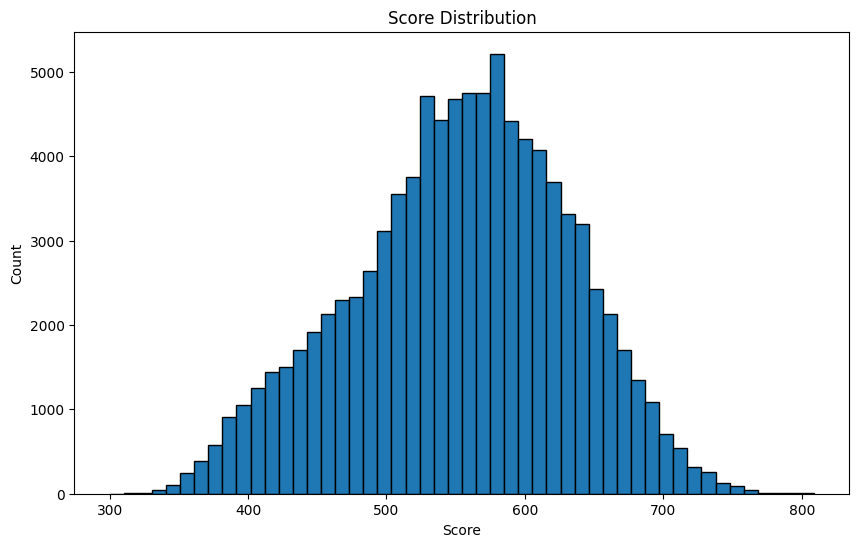

In [31]:
plt.figure(figsize=(10, 6))
plt.hist(y_scores, bins=50, edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Score Distribution')
plt.show()

/var/folders/3f/k0n5zmg91134qrn136jl1q480000gn/T/ipykernel_19603/2063601516.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_analysis[df_analysis['Actual'] == 1], x='Score', label='Good Customers', shade=True, color='blue')
/var/folders/3f/k0n5zmg91134qrn136jl1q480000gn/T/ipykernel_19603/2063601516.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_analysis[df_analysis['Actual'] == 0], x='Score', label='Bad Customers', shade=True, color='red')


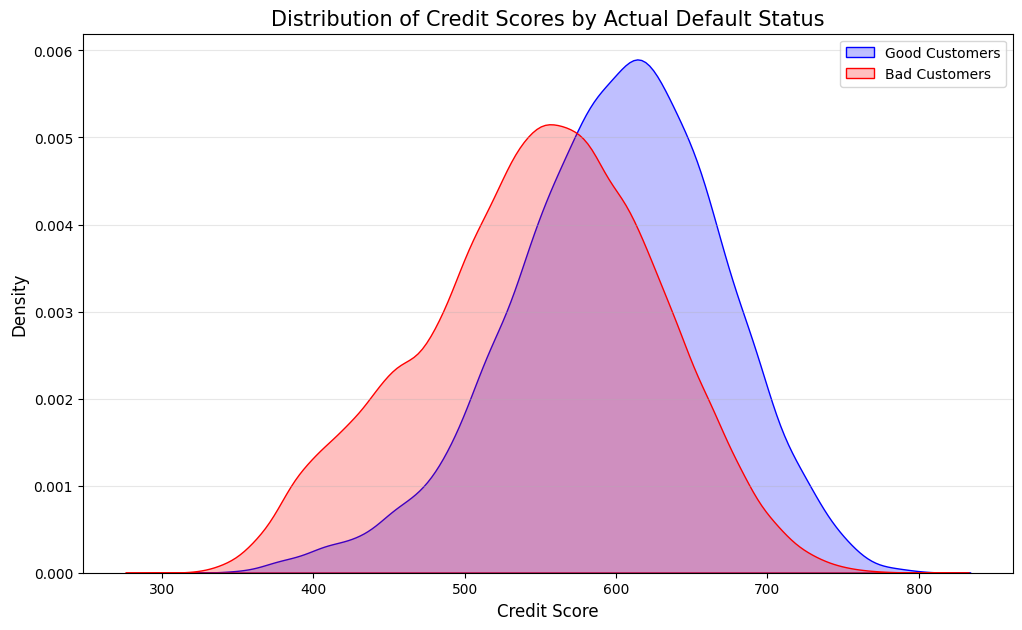

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data (Combine y_test and y_scores)
# Convert y_scores to values in case it is a DataFrame/Series
df_analysis = pd.DataFrame(y_test.values, columns=['Actual'], index=y_test.index)
df_analysis['Score'] = y_scores.values

# 2. Visualization: Distribution of Scores by Actual Default Status
plt.figure(figsize=(12, 7))

# Distinguish between Actual 1 (Good - Repaid) and Actual 0 (Bad - Defaulted)
# Plotting Kernel Density Estimation (KDE) for each group
sns.kdeplot(data=df_analysis[df_analysis['Actual'] == 1], x='Score', label='Good Customers', shade=True, color='blue')
sns.kdeplot(data=df_analysis[df_analysis['Actual'] == 0], x='Score', label='Bad Customers', shade=True, color='red')

plt.title('Distribution of Credit Scores by Actual Default Status', fontsize=15)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

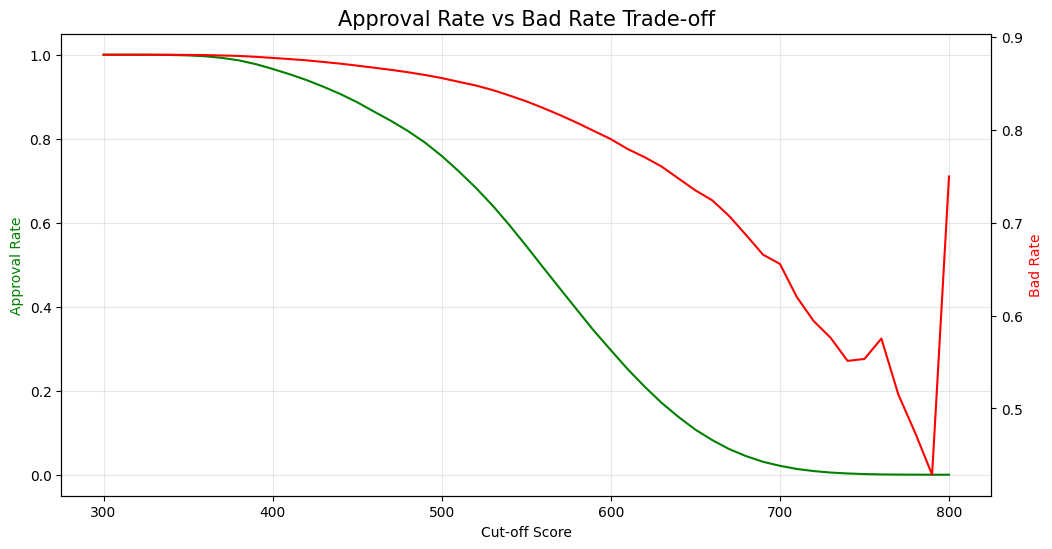

--- Cut-off Strategy Table (Sample) ---
 Cut-off Score  Approval Rate  Bad Rate
           300       1.000000  0.881189
           350       0.998370  0.881005
           400       0.966137  0.877734
           450       0.886807  0.869421
           500       0.758978  0.856047
           550       0.544742  0.830988
           600       0.296653  0.790240
           650       0.107391  0.734998
           700       0.021275  0.655746
           750       0.001608  0.553333
           800       0.000043  0.750000


In [33]:
# 1. Create ranges for each score point
thresholds = np.sort(df_analysis['Score'].unique())
summary_data = []

# Analyze in increments of 10 points from 300 to 850
for cut_off in range(300, 851, 10): 
    # Customers above the cut-off are considered 'Approved'
    approved = df_analysis[df_analysis['Score'] >= cut_off]
    
    if len(approved) > 0:
        approval_rate = len(approved) / len(df_analysis)
        # Proportion of actual defaults (0) among the approved customers
        bad_rate = len(approved[approved['Actual'] == 0]) / len(approved)
        
        summary_data.append([cut_off, approval_rate, bad_rate])

df_cutoff = pd.DataFrame(summary_data, columns=['Cut-off Score', 'Approval Rate', 'Bad Rate'])

# 2. Visualization of the Trade-off Relationship
fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
ax1.plot(df_cutoff['Cut-off Score'], df_cutoff['Approval Rate'], 'g-', label='Approval Rate')
ax2.plot(df_cutoff['Cut-off Score'], df_cutoff['Bad Rate'], 'r-', label='Bad Rate (in Approved)')

ax1.set_xlabel('Cut-off Score')
ax1.set_ylabel('Approval Rate', color='g')
ax2.set_ylabel('Bad Rate', color='r')

plt.title('Approval Rate vs Bad Rate Trade-off', fontsize=15)
ax1.grid(alpha=0.3)
plt.show()

# 3. Sample output of the strategy table
print("--- Cut-off Strategy Table (Sample) ---")
# Displaying summarized results in increments of 50 points
print(df_cutoff.iloc[::5, :].to_string(index=False))